# Geological Modeling with GemPy - Tharsis AOI 1

This notebook demonstrates 3D geological modeling using GemPy for the Tharsis Area of Interest 1. The workflow includes data preprocessing, model creation, and visualization of geological structures.

## 1. Import Required Libraries and Setup Configuration

Import necessary libraries for geological modeling, data processing, and visualization.

In [1]:
import os
import threading
import gempy as gp
import pandas as pd
import HelperMethods

# Setup base directory
BASE_DIR = os.getcwd()
print(f"Base directory: {BASE_DIR}")

Setting Backend To: AvailableBackends.numpy
Base directory: c:\Users\mrcon\PycharmProjects\Mineye-Terranigma-1\GeoModel


## 2. Define File Paths and Model Parameters

Set up all file paths for input data and define model configuration parameters.

In [2]:
# Define data directory and file paths
data_dir = os.path.join(BASE_DIR, '..', 'Data', 'Tharsis AOI 1')

path_to_data = os.path.join(data_dir, 'formationinputpoints_reduced.csv')
path_to_orientations = os.path.join(data_dir, 'orientations_reduced.csv')
path_to_topography = os.path.join(data_dir, 'topo.tif')
path_to_topography_cleaned = os.path.join(data_dir, 'topo_cleaned.tif')
path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced.tif')

# Model parameters
invalid_below = -100  # Define what we consider invalid topography
model_depth = -500  # Define the depth of the model
topo_reduction_factor = 0.1  # Define the factor by which to reduce the topography resolution

# Processing triggers
trigger_create_cross_section = True  # Set to True if you want to create a cross section
trigger_drop_lithologies = False  # Set to True if you want to drop certain lithologies

# Lithologies to optionally drop
lithologies_to_drop = [
    "Upper Carboniferous Volcanics",
    "Tournaisian Plutonites"
]

print("File paths and parameters configured successfully!")

File paths and parameters configured successfully!


## 3. Load and Examine Input Data

Load CSV files containing formation points and orientation data, then examine the data structure and calculate bounding box coordinates.

In [3]:
# Load geological data
points_df = pd.read_csv(path_to_data, encoding='latin1', engine='python')
orientations_df = pd.read_csv(path_to_orientations, encoding='latin1', engine='python')

print("Data loaded successfully!")
print(f"Formation points shape: {points_df.shape}")
print(f"Orientations shape: {orientations_df.shape}")

# Display first few rows
print("\nFormation points (first 5 rows):")
display(points_df.head())

print("\nOrientations (first 5 rows):")
display(orientations_df.head())

Data loaded successfully!
Formation points shape: (4, 5)
Orientations shape: (7, 8)

Formation points (first 5 rows):


,X,Y,Z,formation,formation_id
0,-697098,4543927,271,Upper Devonian Siliciclastics,40
1,-705656,4548904,357,Mid Carboniferous Shales,76
2,-700314,4545329,346,Upper Devonian Siliciclastics,40
3,-704835,4530651,344,Visean Shales,67



Orientations (first 5 rows):


,X,Y,Z,azimuth,dip,polarity,formation,formation_id
0,-697098,4543927,271,284,55,-1,Upper Devonian Siliciclastics,40
1,-681850,4530352,161,286,47,-1,Upper Devonian Siliciclastics,40
2,-681855,4530372,286,318,30,-1,Upper Devonian Siliciclastics,40
3,-705656,4548904,357,134,38,-1,Mid Carboniferous Shales,76
4,-704549,4547233,500,105,30,-1,Upper Devonian Siliciclastics,40


In [4]:
# Define coordinate bounds from the data
top_right = (-678192, 4549947)
bottom_right = (-677518, 4529455)
bottom_left = (-706792, 4528453)
top_left = (-707522, 4548927)


# Calculate bounding box of the area of interest
min_x = min(top_left[0], bottom_left[0])
max_x = max(top_right[0], bottom_right[0])
min_y = min(bottom_left[1], bottom_right[1])
max_y = max(top_left[1], top_right[1])
max_z = points_df['Z'].max()

print(f"Bounding box calculated:")
print(f"X range: {min_x} to {max_x}")
print(f"Y range: {min_y} to {max_y}")
print(f"Z range: {model_depth} to {max_z}")

Bounding box calculated:
X range: -707522 to -677518
Y range: 4528453 to 4549947
Z range: -500 to 357


## 4. Clean and Preprocess Topography Data

Process the topography data by cleaning invalid values and reducing resolution for computational efficiency.

In [5]:
# Clean topography file
print("Cleaning topography file...")
HelperMethods.clean_topo_file(path_to_topography, path_to_topography_cleaned)

# Reduce topography resolution
print(f"Reducing topography resolution by factor {topo_reduction_factor}...")
HelperMethods.reduce_tif_resolution(
    input_path=path_to_topography_cleaned,
    output_path=path_to_topography_reduced,
    scale_factor=topo_reduction_factor
)

# Update path with scale factor suffix
base, ext = os.path.splitext(path_to_topography_reduced)
path_to_topography_reduced = f"{base}_sf{topo_reduction_factor}{ext}"

print(f"Processed topography saved to: {path_to_topography_reduced}")

Cleaning topography file...
Reducing topography resolution by factor 0.1...
Processed topography saved to: c:\Users\mrcon\PycharmProjects\Mineye-Terranigma-1\GeoModel\..\Data\Tharsis AOI 1\topo_reduced_sf0.1.tif


## 5. Filter Lithologies (Optional)

Optionally remove specified lithologies from the dataset based on trigger settings.

In [6]:
# Conditionally drop lithologies
if trigger_drop_lithologies:
    print("Dropping specified lithologies...")
    print(f"Lithologies to drop: {lithologies_to_drop}")
    HelperMethods.drop_lithologies(points_df, orientations_df, lithologies_to_drop)
    print("Lithologies dropped successfully!")
else:
    print("Lithology filtering is disabled - keeping all lithologies")

Lithology filtering is disabled - keeping all lithologies


## 6. Create GemPy Geological Model

Initialize the geological model using GemPy with specified extent, refinement, and input data.

In [7]:
# Create the geological model
print("Creating GemPy geological model...")

# geo_model = gp.create_geomodel(
#     project_name='AOI',
#     extent=[min_x, max_x, max_y, min_y, model_depth, max_z],
#     refinement=6,
#     importer_helper=gp.data.ImporterHelper(
#         path_to_orientations=os.path.join(BASE_DIR, "temp_orientations.csv"),
#         path_to_surface_points=os.path.join(BASE_DIR, "temp_points.csv"),
#     )
# )

geo_model = gp.create_geomodel(
    project_name='AOI',
    extent=[min_x, max_x, max_y, min_y, model_depth, max_z],
    refinement=6,
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations='sampled_orientationinputpoints.csv',
        path_to_surface_points='sampled_formationinputpoints.csv',
    )
)

print("Geological model created successfully!")

Creating GemPy geological model...
Geological model created successfully!


In [86]:
test = pd.read_csv('sampled_formationinputpoints.csv', encoding='latin1', engine='python')
test['formation'].unique()

array(['Upper Devonian Siliciclastics', 'Visean Shales',
       'Tournaisian Plutonites', 'Upper Carboniferous Volcanics',
       'Mid Carboniferous Shales'], dtype=object)

## 7. Configure Model Stack and Surfaces

Map geological stacks to surfaces and apply color schemes to lithologies.

In [12]:
# Map geological stacks to surfaces
print("Configuring geological stacks and surfaces...")

gp.map_stack_to_surfaces(
    gempy_model=geo_model,
    mapping_object={
        # Alternative configurations (commented):
        # "Strat_Series2": ("Visean Shales", "Mid Carboniferous Shales"),
        # "Strat_Series2": ("Upper Carboniferous Volcanics", "Visean Shales"),
        "Strat_Series2": "Tournaisian Plutonites",
        "Strat_Series1": ("Mid Carboniferous Shales", "Visean Shales", "Upper Devonian Siliciclastics")
    }
)

# Apply color scheme to lithologies
print("Applying color scheme to lithologies...")
HelperMethods.color_lithology(geo_model.structural_frame.structural_elements)

print("Model configuration completed!")

Configuring geological stacks and surfaces...
Applying color scheme to lithologies...
Model configuration completed!


## 8. Set Topography and Compute Model

Apply topography from the processed file to the model grid and compute the geological model.

In [43]:
# Set topography from processed file
print("Setting topography...")
gp.set_topography_from_file(grid=geo_model.grid, filepath=path_to_topography_reduced)

# Compute the geological model
print("Computing geological model... (this may take a while)")
gempy_model = gp.compute_model(geo_model)

print("Model computation completed successfully!")

Setting topography...
Active grids: GridTypes.NONE|TOPOGRAPHY|OCTREE
Computing geological model... (this may take a while)
Setting Backend To: AvailableBackends.numpy


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 7 chunks
Chunking done: 6 chunks
Chunking done: 6 chunks
Chunking done: 7 chunks
Chunking done: 7 chunks
Chunking done: 6 chunks
Chunking done: 6 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Model computation completed successfully!


## 9. Visualize 3D Model

Create 3D visualization of the geological model using asynchronous plotting.

In [44]:
# Create 3D visualization (asynchronous)
print("Starting 3D visualization...")
threading.Thread(target=HelperMethods.plot_3d_async, args=(geo_model,)).start()

print("3D visualization initiated! Check for the plotting window.")

Starting 3D visualization...
3D visualization initiated! Check for the plotting window.
3D visualization initiated! Check for the plotting window.


## 10. Create Cross Sections

Generate cross-sectional views of the geological model when enabled.

Creating cross section...


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:17

Cross section created!


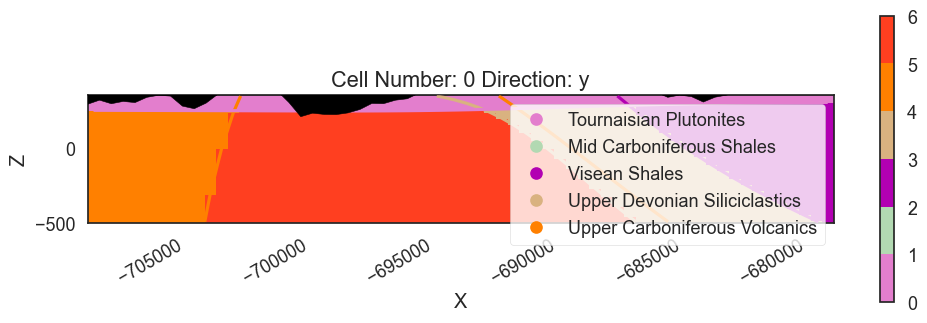

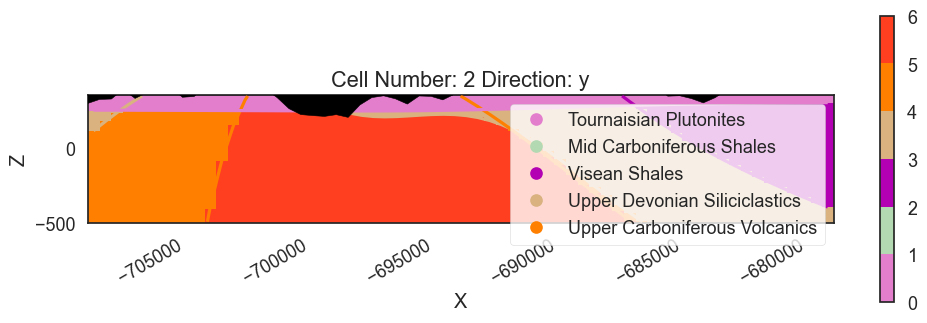

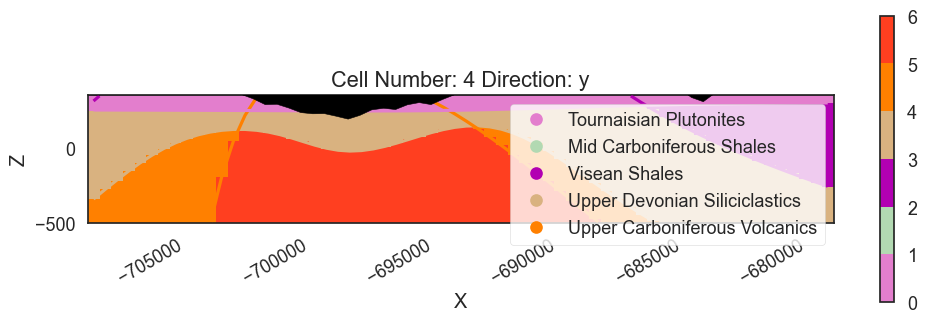

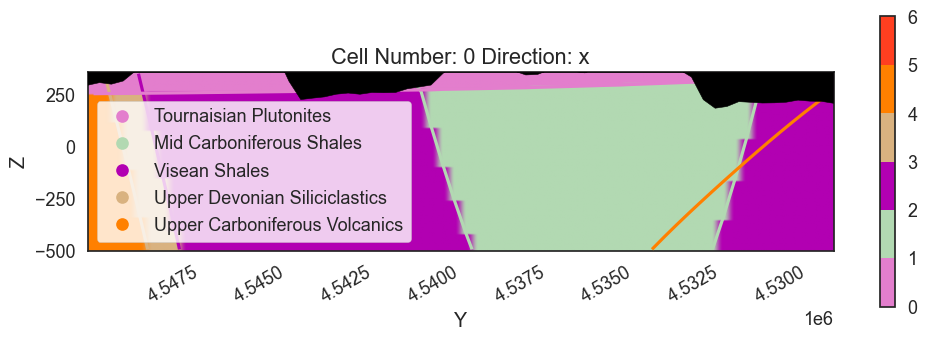

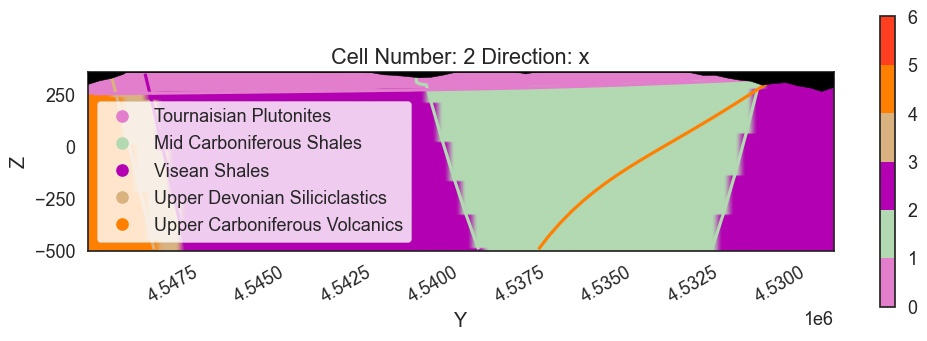

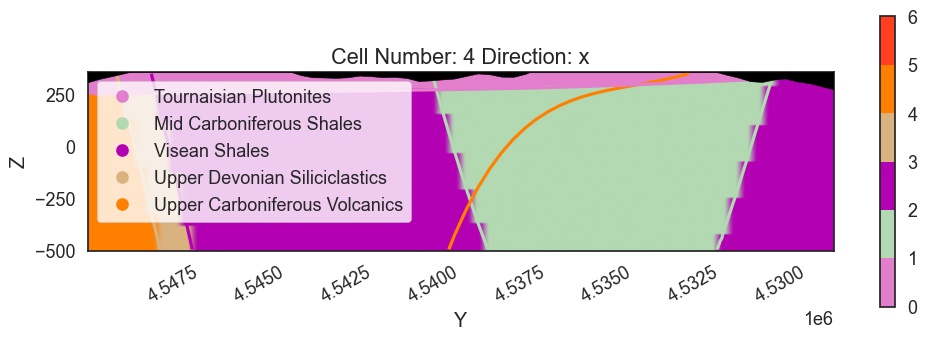

In [45]:
# Create cross sections if enabled
if trigger_create_cross_section:
    print("Creating cross section...")
    HelperMethods.create_cross_section(geo_model, cross_section=5)
    print("Cross section created!")
else:
    print("Cross section creation is disabled")

## 11. Visualize Geological Model from Above (Top-Down)

Create a map-view (top-down) visualization of the modeled geology to inspect the lateral distribution of lithologies and boundaries.

Rendering top-down (Z-direction) 2D geological map...


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


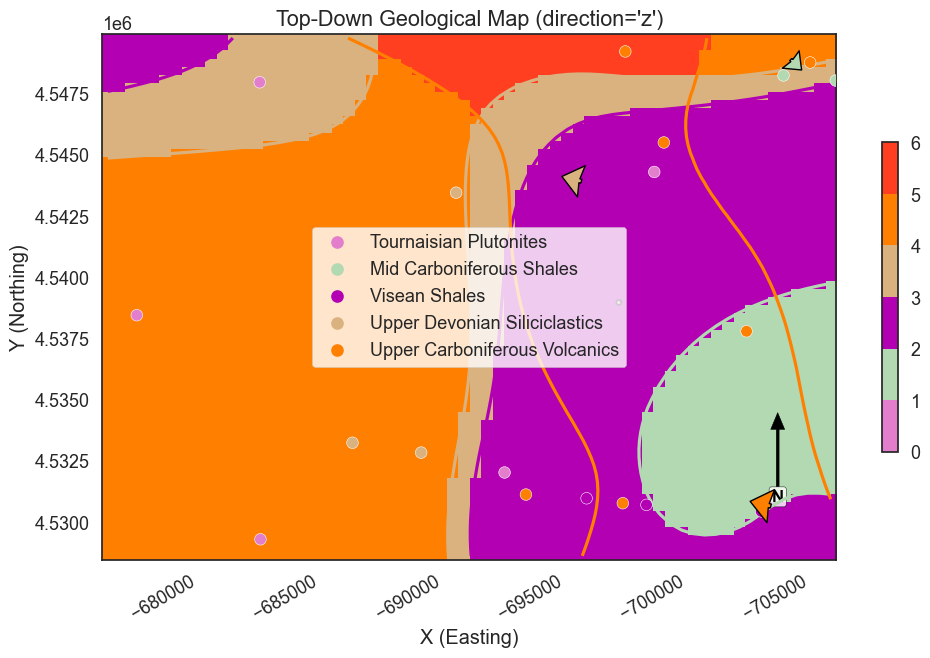

In [46]:
# Top-down (map-view) visualization of the geological model
import gempy_viewer as gpv
import matplotlib.pyplot as plt

print("Rendering top-down (Z-direction) 2D geological map...")

# Use GemPy viewer to generate the plot and return handles (prevents extra empty figures)
ret = gpv.plot_2d(
    geo_model,
    direction="z",
    show_lith=True,
    show_boundaries=True,
    show_data=True,
    legend=True
)

# Normalize to (fig, ax) regardless of return shape
try:
    fig, ax = ret
except Exception:
    fig = plt.gcf()
    ax = plt.gca()

# Title, labels, and aspect
ax.set_title("Top-Down Geological Map (direction='z')")
ax.set_xlabel('X (Easting)')
ax.set_ylabel('Y (Northing)')
ax.set_aspect('equal')

# Rotate view 180° by inverting both axes
ax.invert_xaxis()
ax.invert_yaxis()

# Add a North arrow that always points to True North in screen space
arrow_tail = (0.92, 0.28)
arrow_head = (0.92, 0.12)   # arrow points up (True North)

ax.annotate(
    'N',
    xy=arrow_tail,            # arrow tail (in axes fraction)
    xytext=arrow_head,        # arrow head position
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(facecolor='black', edgecolor='black', width=2, headwidth=10),
    ha='center', va='center', fontsize=12, color='black', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='black', alpha=0.8)
)

plt.tight_layout()
# Avoid extra plt.show(); rely on notebook auto-render or the viewer's own display.

c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_sections_api.py:106: UserWarning: Section contacts not implemented yet. We need to pass scalar field for the sections grid
  warnings.warn(
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


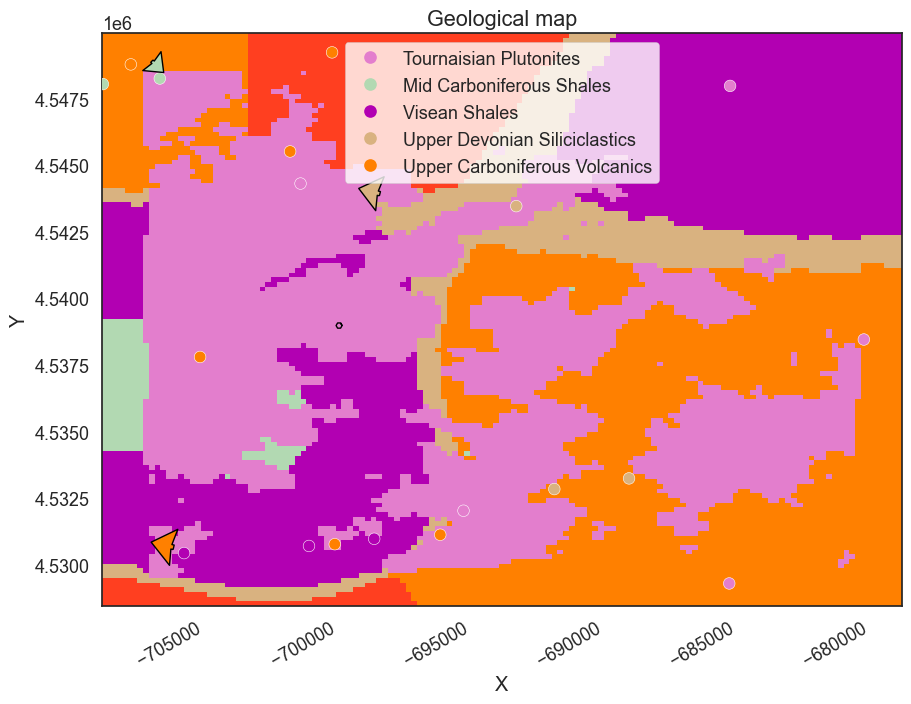

In [ ]:
ret = gpv.plot_2d(
    geo_model,
    direction="z",
    section_names=['topography'],
    # show_topography=True,
    show_lith=True,
    show_boundaries=True,
    show_data=True,
    legend=True
)

fig = plt.gcf()
ax = plt.gca()
ax.invert_yaxis()
plt.show()

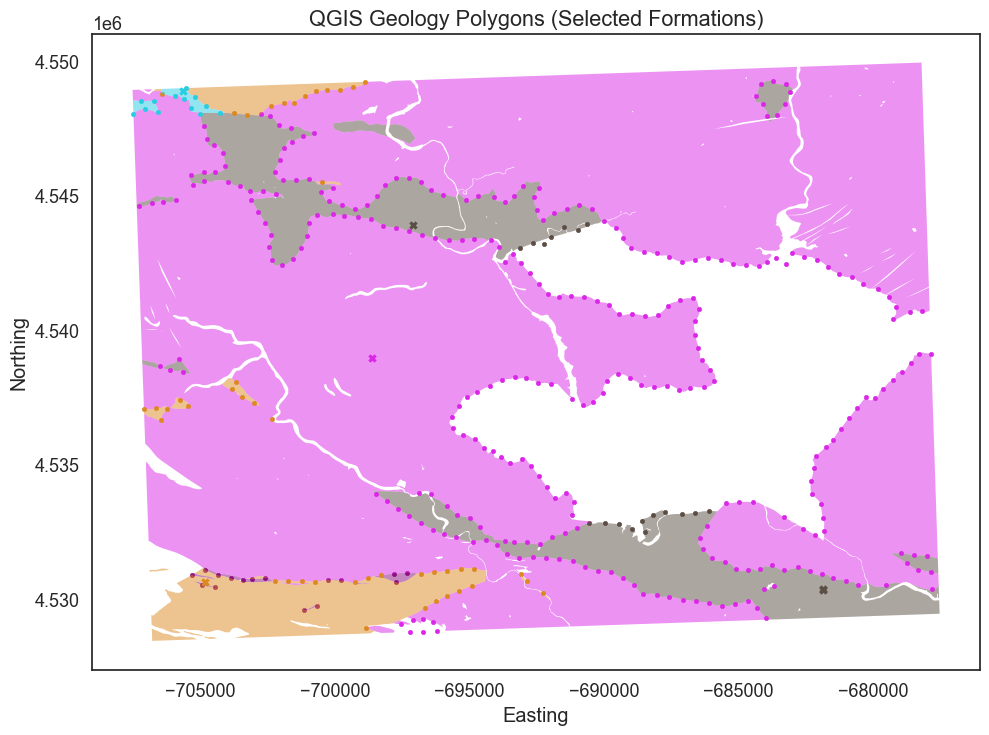

In [148]:
import geopandas as gpd

# Load the QGIS geology data
gdf = gpd.read_file(r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\clippedGeologyEn3.gpkg")
path_to_data = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\formationinputpoints.csv"
points_df = pd.read_csv(path_to_data, encoding='latin1', engine='python')

path_to_orientations = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\orientations.csv"
orientations_df = pd.read_csv(path_to_orientations, encoding='latin1', engine='python')

gdf['GEOLOGY'] = gdf['GEOLOGY'].replace('Purple to multicolored shales and mudstones with radiolarian-rich beds – Purple shales','Visean Shales')


formations = [
    'Upper Devonian Siliciclastics',
    'Visean Shales',
    'Tournaisian Plutonites',
    'Upper Carboniferous Volcanics',
    'Mid Carboniferous Shales'
]
colors = ["#5B4E45", "#8D0F82FF","#DB26E8", "#DD8820", "#26CDE3"]

fig, ax = plt.subplots(figsize=(10, 10))
for formation, colour in zip(formations, colors):
    gdf[gdf['GEOLOGY'] == formation].plot(ax=ax, color=colour, alpha=0.5)
    ax.scatter(points_df[points_df['formation'] == formation]['X'], points_df[points_df['formation'] == formation]['Y'], color=colour, s=10, label=formation)
    ax.scatter(orientations_df[orientations_df['formation'] == formation]['X'], orientations_df[orientations_df['formation'] == formation]['Y'], color=colour, s=20, marker='x', label=f"{formation} Orientations")
    

ax.set_title('QGIS Geology Polygons (Selected Formations)')
ax.set_xlabel('Easting')
ax.set_ylabel('Northing')
ax.set_aspect('equal')
# ax.legend()
plt.tight_layout()
plt.show()